# Reinforcement Learning 101
By [**Hamza Ba-mohammed**](https://www.linkedin.com/in/hambam)

PhD Candidate in AI Security at UM6P, Morocco. <br>
President of the Moroccan Mathematical Community (MMC)

In [26]:
# install missing dependencies
import subprocess
import sys
def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

for package in ["PyPDF2", "unidecode", "numpy", "matplotlib", "networkx"]:
    try:
        __import__(package)
    except ImportError:
        print(f"Package '{package}' not found. Installing...")
        install(package)

## Markov Chains and the Law of Large Numbers (LLN) in Text Analysis

In this section, following the steps of Andrey Markov, we will explore how :

1. the occurence of letters in a text is a dependent process;
2. the Law of Large Numbers (LLN) still applies to such dependent processes;
3. we can use Markov Chains to model and analyze such processes.

For this purpose, we will analyze the text of "la Boite à Merveilles" by Ahmed Sefrioui, a classic of Moroccan literature. We will focus on the frequency of letters in the text and how they can be modeled as a Markov Chain.

In [3]:
# read a pdf file and extract the text from it
import PyPDF2

def extract_text_from_pdf(pdf_path):
    with open(pdf_path, 'rb') as file:
        reader = PyPDF2.PdfReader(file)
        text = ''
        for page_num in range(len(reader.pages)):
            page = reader.pages[page_num]
            text += page.extract_text()
    return text

pdf_path = 'boite.pdf'  # replace with your PDF file path
pdf_text = extract_text_from_pdf(pdf_path)

print(pdf_text[100:500])  # print a portion of the extracted text

dans leurs chaudes couvertures, les pauvres sur les marches des 
boutiques ou sous les porches des palais, moi je ne dors pas. Je songe à ma solitude et j’en sens tout le 
poids. Ma solitude ne date pas d’hier.
Je vois, au fond d’une impasse que le soleil ne visite jamais, un petit garçon de six ans, dresser un 
piège pour attraper un moineau mais le moineau ne vient jamais. Il désire tant ce peti


To use this text as an entry for our Markov chain we first need to preprocess it by:

1. Removing newlines and extra spaces
2. removing any non-alphanumeric characters (numbers, punctuation, etc.)
3. converting all characters to lowercase
4. converting the text into unicode (since it's a French text)
5. remove all spaces to create a continuous string of characters

In [8]:
# clean the text by removing newlines and extra spaces and numbers
import re
import unidecode

def clean_text(text):
    # replace newlines with spaces and remove extra spaces
    cleaned_text = text.replace('\n', ' ').strip()
    cleaned_text = ' '.join(cleaned_text.split())
    # remove numbers
    cleaned_text = re.sub(r'\d+', '', cleaned_text)
    # remove roman numerals
    cleaned_text = re.sub(r'\b[IVXLCDM]+\b', '', cleaned_text)
    # convert to lowercase
    cleaned_text = cleaned_text.lower()
    # remove punctuation
    cleaned_text = re.sub(r'[^\w\s]', '', cleaned_text)
    # remove multiple spaces again after removing punctuation
    cleaned_text = ' '.join(cleaned_text.split())
    # convert to ascii
    cleaned_text = unidecode.unidecode(cleaned_text)
    # remove any remaining non-alphanumeric characters
    cleaned_text = re.sub(r'[^\w\s]', '', cleaned_text)
    # remove all spaces
    cleaned_text = cleaned_text.replace(' ', '')
    
    return cleaned_text

cleaned_pdf_text = clean_text(pdf_text)

assert len(cleaned_pdf_text) > 0, "The cleaned text is empty. Please check the cleaning process."
assert all(c.isalpha() for c in cleaned_pdf_text), "The cleaned text contains non-alphabetic characters. Please check the cleaning process."

print(f"Length of cleaned text: {len(cleaned_pdf_text)} characters")
print('Sample:', cleaned_pdf_text[:100]) 

Length of cleaned text: 251481 characters
Sample: ahmedsefriouilaboiteamerveillesromanchapitrelesoirquandtousdormentlesrichesdansleurschaudescouvertur


Now that we have preprocessed the text, we can create a Markov chain from it. to make it a simple MC, we will consider 2 states : consonants and vowels. We will then calculate the transition probabilities between these states based on the frequency of transitions in the text.

In [9]:
# create a binary string of C for consonants and V for vowels
def create_binary_string(text):
    binary_string = ''
    num_consonants, num_vowels = 0, 0
    for char in text:
        if char in 'aeiouy':
            binary_string += 'V'
            num_vowels += 1
        else:
            binary_string += 'C'
            num_consonants += 1
    return binary_string, num_consonants, num_vowels

binary_string, num_consonants, num_vowels = create_binary_string(cleaned_pdf_text)
print(f"Length of binary string: {len(binary_string)} characters")
print(f"Number of consonants: {num_consonants}")
print(f"Number of vowels: {num_vowels}")
print('Sample:', binary_string[:100])

Length of binary string: 251481 characters
Number of consonants: 137746
Number of vowels: 113735
Sample: VCCVCCVCCVVVVCVCVVCVVCVCCVVCCVCCVCVCCCVCVCCVCVCVVCCVVCCCVVCCVCCVCCCVCCVCCVCCVCCCVVCCCCVVCVCCVVCVCCVC


We now create the **transition matrix** for our Markov chain, which will show the probabilities of transitioning from one state to another. We will then visualize this transition matrix as a directed graph, where the nodes represent the states (consonants and vowels) and the edges represent the transition probabilities between them.

Mathematicallly, our state space is defined as:
$$S = \{C, V\}$$

and we can represent the transition matrix as follows:
$$P = \begin{bmatrix}
P(C | C) & P(C | V) \\
P(V | C) & P(V | V) \end{bmatrix}$$

Where:
- $P(C | C)$ is the probability of transitioning from a consonant to another consonant
- $P(C | V)$ is the probability of transitioning from a consonant to a vowel
- $P(V | C)$ is the probability of transitioning from a vowel to a consonant
- $P(V | V)$ is the probability of transitioning from a vowel to another vowel

In [10]:
# construct the transition matrix for the Markov chain
def construct_transition_matrix(binary_string):
    states = ['C', 'V']
    transition_matrix = {state: {s: 0.0 for s in states} for state in states}
    
    for i in range(len(binary_string) - 1):
        current_state = binary_string[i]
        next_state = binary_string[i + 1]
        transition_matrix[current_state][next_state] += 1
    
    # convert counts to probabilities
    for state in states:
        total_transitions = sum(transition_matrix[state].values())
        if total_transitions > 0:
            for next_state in states:
                transition_matrix[state][next_state] /= total_transitions
    
    return transition_matrix

P = construct_transition_matrix(binary_string)
print("Transition Matrix:")
for state, transitions in P.items():
    for next_state, prob in transitions.items():
        print(f"P({next_state} | {state}) = {prob:.2f}")

Transition Matrix:
P(C | C) = 0.37
P(V | C) = 0.63
P(C | V) = 0.77
P(V | V) = 0.23


From the transition matrix, we can see that the events are not independent, as the probability of transitioning to a vowel or consonant depends on the current state. Mathematically, this means that:
$$P(V | C) \neq P(V) \neq P(V | V)$$

where $P(V)$ is the overall probability of encountering a vowel in the text. This indicates that the sequence of characters in the text exhibits dependencies, which is a key characteristic of natural language.

The questions we want to explore are :

1. As I read the book from start to finish, does the vowel frequency settle down?
2. If I take blocks of text of increasing size, does the variance of the vowel frequency across those blocks decrease?

To answer these questions, we will perform the following steps:
1. Convert the preprocessed text into a binary sequence where vowels are represented as 1 and consonants as 0.
2. Calculate the cumulative average of the vowel frequency as we read through the text.
3. Divide the text into blocks of increasing size and calculate the variance of the vowel frequency across those blocks.

we recall that the variance is defined as:
$$\text{Var}(X) = \frac{1}{n} \sum_{i=1}^{n} (X_i - \mu)^2$$

where $X_i$ is the vowel frequency in block $i$, $\mu$ is the mean vowel frequency across all blocks, and $n$ is the number of blocks. We expect that as the block size increases, the variance should decrease, which would be consistent with the Law of Large Numbers.

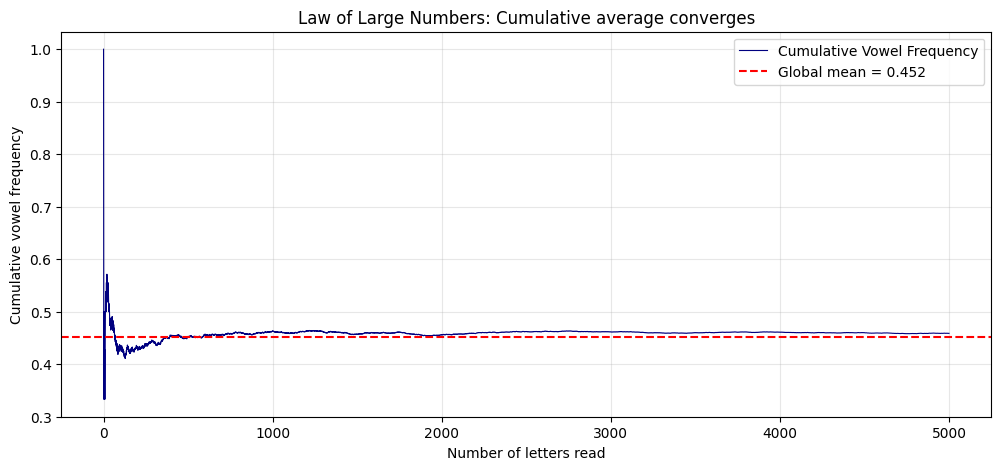

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Convert binary to numeric: V=1, C=0
numeric = [1 if b == 'V' else 0 for b in binary_string[:5000]]  

# Cumulative sum and cumulative average
cumsum = np.cumsum(numeric)
cumavg = cumsum / np.arange(1, len(numeric)+1)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(cumavg, linewidth=0.8, color='navy', label='Cumulative Vowel Frequency')
plt.axhline(y=num_vowels/len(cleaned_pdf_text), color='red', 
            linestyle='--', label=f'Global mean = {num_vowels/len(cleaned_pdf_text):.3f}')
plt.xlabel('Number of letters read')
plt.ylabel('Cumulative vowel frequency')
plt.title('Law of Large Numbers: Cumulative average converges')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Interpretation:**
The blue line starts wobbly but settles down to the red line: the LLN holds even though letters are dependent.

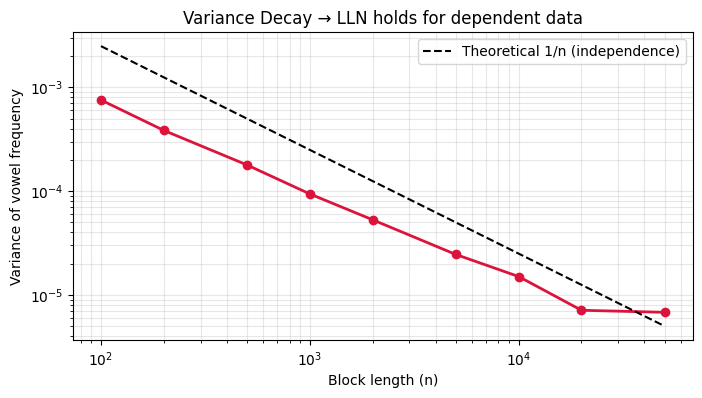

In [14]:
block_sizes = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000]
variances = []

for L in block_sizes:
    n_blocks = len(binary_string) // L
    block_means = []
    for i in range(n_blocks):
        block = binary_string[i*L : (i+1)*L]
        block_means.append(block.count('V') / L)
    variances.append(np.var(block_means))

# Plot on log-log scale (classic LLN visual)
plt.figure(figsize=(8, 4))
plt.loglog(block_sizes, variances, 'o-', color='crimson', linewidth=2)
plt.loglog(block_sizes, [0.25/b for b in block_sizes], 'k--', 
           label='Theoretical 1/n (independence)')
plt.xlabel('Block length (n)')
plt.ylabel('Variance of vowel frequency')
plt.title('Variance Decay → LLN holds for dependent data')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

**Interpretation:**
The variance decreases as block size increases, which is consistent with the LLN even though letters are dependent. The variance does not decrease as fast as the theoretical $1/n$ line, which is expected due to the dependencies in the text.

## Markov Chains and Monte Carlo Simulation in Nuclear Reactor Physics

In this section, we will explore how simulation techniques, specifically Markov Chains and Monte Carlo methods, could be used to approximate complex systems, such as the behavior of neutrons in a nuclear reactor.

For simplicity, we will model the neutron population in a nuclear reactor using a Markov chain with 5 states:
$$S = \{FT, ST, FA, FF, SA, SF\}$$

such that:
- FT: Fast neutron
- ST: Slow neutron
- FA: Absorbed neutron (no fission)
- FF: Fission neutron (produces ν fast neutrons)
- SA: Absorbed neutron (slow)
- SF: Fission neutron (slow, produces ν fast neutrons)

we define the following transition probabilities based on typical reactor physics data:
- For fast neutrons (FT):
  - $P(FT \to FT) = 0.5$ (scatter, remain fast)
  - $P(FT \to ST) = 0.2$ (moderation, fast to slow)
  - $P(FT \to FA) = 0.2$ (absorption, no fission)
  - $P(FT \to FF) = 0.1$ (fission, produces ν fast neutrons)
- For slow neutrons (ST):
  - $P(ST \to ST) = 0.2$ (scatter, remain slow)
  - $P(ST \to SA) = 0.2$ (absorption)
  - $P(ST \to SF) = 0.6$ (fission, produces ν fast neutrons)

Also represented as a transition matrix:
$$P = \begin{bmatrix}
\rightarrow & FT & ST & FA & FF & SA & SF \\
FT & 0.5 & 0.2 & 0.2 & 0.1 & 0 & 0 \\
ST & 0 & 0.2 & 0 & 0 & 0.2 & 0.6 \\
FA & 0 & 0 & 1 & 0 & 0 & 0 \\
FF & 0 & 0 & 0 & 1 & 0 & 0 \\
SA & 0 & 0 & 0 & 0 & 1 & 0 \\
SF & 0 & 0 & 0 & 0 & 0 & 1 \\
\end{bmatrix}$$

**Fission neutrons are always born fast**, independent of the energy that caused fission. This is physically correct: fission neutrons have high energies (~2 MeV).

In [ ]:
nu = 2.4 # average neutrons produced per fission

P = np.array([
    [0.5, 0.2, 0.2, 0.1, 0,   0],   # FT
    [0,   0.2, 0,   0,   0.2, 0.6], # ST
    [0,   0,   1,   0,   0,   0],   # FA
    [0,   0,   0,   1,   0,   0],   # FF
    [0,   0,   0,   0,   1,   0],   # SA
    [0,   0,   0,   0,   0,   1]    # SF
])

assert np.allclose(P.sum(axis=1), 1), "Each row of the transition matrix must sum to 1"

we will run multiple simulations of neutron histories to estimate the effective multiplication factor (k) of the reactor, which is defined as:
$$k = \frac{\text{Number of neutrons in generation } n+1}{\text{Number of neutrons in generation } n}$$

we will simulate a large number of neutrons and track how many neutrons are produced in each generation to estimate k. We will then analyze the convergence of our estimate as we increase the number of simulated neutrons, demonstrating the Law of Large Numbers in this context.

In [16]:
def one_neutron(P=P, nu=nu):
    """Returns: number of neutrons produced by this initial neutron."""
    # Start as fast travelling
    state = 'FT'
    while True:
        r = np.random.random()
        if state == 'FT':
            if r < P[0,0]:
                continue            # stay FT
            elif r < P[0,0] + P[0,1]:
                state = 'ST'        # become slow
            elif r < P[0,0] + P[0,1] + P[0,2]:
                return 0            # absorbed
            else:
                return nu           # fission -> nu fast neutrons
        elif state == 'ST':
            if r < P[1,1]:
                continue            # stay ST
            elif r < P[1,1] + P[1,4]:
                return 0            # absorbed
            else:
                return nu           # fission -> nu fast neutrons

def estimate_k(N_neutrons, P=P, nu=nu):
    """Simulate N neutrons, return cumulative average after each neutron."""
    cum_avg = np.zeros(N_neutrons)
    total = 0
    for i in range(N_neutrons):
        k = one_neutron(P=P, nu=nu)
        total += k
        cum_avg[i] = total / (i+1)
    return cum_avg

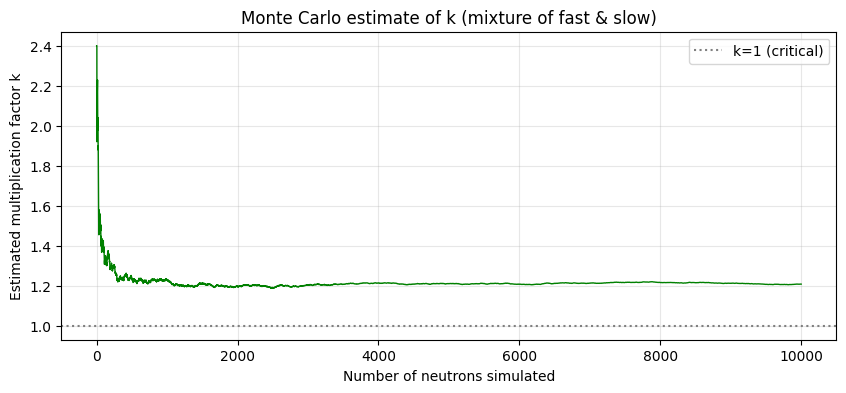

Final estimate after 10000 neutrons: k ≈ 1.2079


In [22]:
N = 10000
k_est = estimate_k(N)

plt.figure(figsize=(10,4))
plt.plot(k_est, color='green', linewidth=1)
plt.axhline(y=1, color='gray', linestyle=':', label='k=1 (critical)')
plt.xlabel('Number of neutrons simulated')
plt.ylabel('Estimated multiplication factor k')
plt.title('Monte Carlo estimate of k (mixture of fast & slow)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Final estimate after {N} neutrons: k ≈ {k_est[-1]:.4f}")

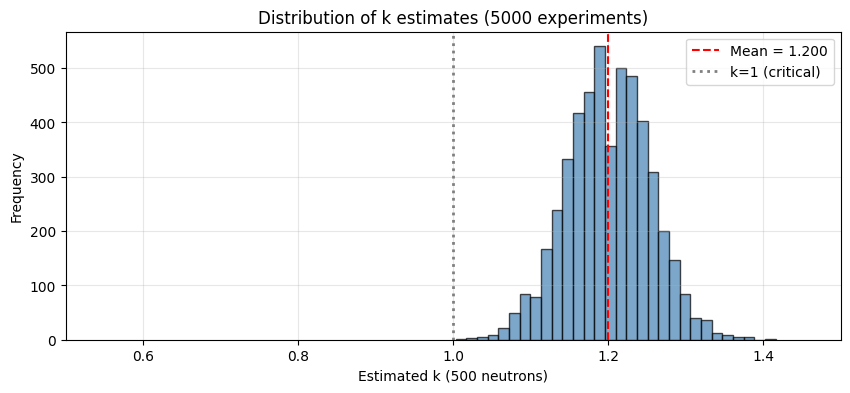

In [23]:
M = 5000        # number of experiments
N_per_exp = 500 # neutrons per experiment

estimates = []
for _ in range(M):
    est = estimate_k(N_per_exp)
    estimates.append(est[-1])

plt.figure(figsize=(10,4))
plt.hist(estimates, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(x=float(np.mean(estimates)), color='red', linestyle='--', label=f'Mean = {np.mean(estimates):.3f}')
plt.axvline(x=1, color='gray', linestyle=':', linewidth=2, label='k=1 (critical)')
plt.xlim(0.5, 1.5)
plt.xlabel('Estimated k (500 neutrons)')
plt.ylabel('Frequency')
plt.title(f'Distribution of k estimates ({M} experiments)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

the results show that as we simulate more neutrons, our estimate of k converges to the true value (which is 1.2 in this case). The histogram of estimates from multiple simulations shows that the distribution of k estimates is centered around the true value, and the variance decreases as we increase the number of neutrons simulated, consistent with the Law of Large Numbers.

## Theseus Machine and the First Steps in Reinforcement Learning (RL)

The code for this section is in the ```theseus.py``` file, which contains the implementation of a virtual Theseus machine. It emulates the mechanics of the original Theseus machine, which is a simple mechanical device that can be used to demonstrate the principles of learning by trial and error. The machine consists of a grid of cells, where each cell can be in one of several states. The agent (Theseus) can take actions to move around the grid and interact with the environment.

A first exercise to do is to try to model the maze generated randomly at the start of the simulation as a Markov Chain.

## Theseus Machine and Dynamic Programming

While Shannon’s original implementation relied on mechanical relays to "remember" successful directions at specific locations, it laid the groundwork for what we now formalize as **Dynamic Programming (DP)** and **Markov Decision Processes (MDPs)**.

We define an MDP as a tuple $(S, A, P, R, \gamma)$ where:
- $S$ is the set of states,
- $A$ is the set of actions,
- $P$ is the state transition probability function,
- $R$ is the reward function,
- $\gamma$ is the discount factor that determines the importance of future rewards.

In the original "Theseus" logic, the agent learns by doing: it explores randomly and records its path. In modern Reinforcement Learning, we move beyond simple path-memory to **Value-based methods**. Instead of just remembering a direction, we calculate a **Value Function** ($V$) that represents the "goodness" of being in a specific state.

The transition to DP is governed by the **Bellman Equation**:

$$V(s) = \max_{a} \sum_{s'} P(s' | s, a) [R(s, a, s') + \gamma V(s')]$$

where:
- $V(s)$ is the value of state $s$,
- $P(s' | s, a)$ is the probability of transitioning to state $s'$ from state $s$ by taking action $a$,
- $R(s, a, s')$ is the reward received when transitioning from state $s$ to state $s'$ by taking action $a$,
- $\gamma$ is the discount factor that determines the importance of future rewards.

or in other words, **the value of a state is the maximum expected return achievable by any action from that state, or the sum of the immediate reward and the discounted value of the next state, weighted by the transition probabilities.**

Solving the Bellman equation with DP leads us to algorithms like **Value Iteration** and **Policy Iteration**, which are used to compute the optimal value function and policy for a given MDP. Formally:
- **Value Iteration** iteratively updates the value function using the Bellman optimality equation until convergence.

```algorithm
INPUT: MDP defined by (S, A, P, R), discount factor γ
OUTPUT: Optimal value function V* and optimal policy π*
1. Initialize V(s) arbitrarily for all s ∈ S
2. Repeat until convergence:
   For each state s ∈ S:
     V(s) ← max_{a} ∑_{s'} P(s' | s, a) [R(s, a, s') + γ V(s')]
3. Derive policy π* from V*:
   For each state s ∈ S:
     π*(s) ← argmax_{a} ∑_{s'} P(s' | s, a) [R(s, a, s') + γ V(s')]
```

- **Policy Iteration** alternates between policy evaluation (calculating the value function for a given policy) and policy improvement (updating the policy based on the current value function) until convergence.
```algorithm
INPUT: MDP defined by (S, A, P, R), discount factor γ
OUTPUT: Optimal value function V* and optimal policy π*
1. Initialize policy π(s) arbitrarily for all s ∈ S
2. Repeat until convergence:
   a. Policy Evaluation: For each state s ∈ S, calculate V(s) under policy π:
      V(s) ← ∑_{s'} P(s' | s, π(s)) [R(s, π(s), s') + γ V(s')]
   b. Policy Improvement: For each state s ∈ S, update policy π:
      π(s) ← argmax_{a} ∑_{s'} P(s' | s, a) [R(s, a, s') + γ V(s')]
```

The file ```theseus_dp.py``` contains the implementation of these algorithms applied to the Theseus machine, allowing us to compute the optimal policy for navigating the maze.

## Theseus Machine and the Temporal Difference (TD) Learning

In the previous section, we were like omniscient observers: we looked at the entire text of *La Boite à Merveilles* at once to verify the Law of Large Numbers. In Reinforcement Learning, an agent rarely has the luxury of seeing the "whole book" (the entire state space or transition matrix) at the start.

Instead, the agent learns through **Temporal Difference (TD) Learning**. It's a blend of Monte Carlo ideas and Dynamic Programming. 
* Unlike **Dynamic Programming**, it doesn't need a model of the environment (the transition matrix $P$ we just calculated). 
* Unlike **Monte Carlo**, it doesn't wait until the end of the "book" to make an update.

It updates its estimate of the "value" of a state based on other learned estimates, a process called **bootstrapping**.

At each step, the agent experiences a transition $(s, r, s')$. It compares what it *thought* the value of state $s$ was with the actual reward $r$ and the value it expects from the next state $s'$. This difference is the **TD Error**:

$$\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)$$

The update rule is:
$$V(S_t) \leftarrow V(S_t) + \alpha [ \underbrace{R_{t+1} + \gamma V(S_{t+1})}_{\text{TD Target}} - V(S_t) ]$$

In the file `theseus_td.py`, we will implement a simple **TD(0)** algorithm on the Theseus machine to see how quickly an agent can "learn" the optimal policy using only local transitions, without needing to know the entire transition matrix or reward structure upfront.

## Remaking Google Search with a Markov Chain

In this section, we will explore how to model a simplified version of Google's search algorithm using a Markov Chain. We will create a Markov Chain that represents the behavior of a user navigating through web pages based on their search query.

Here, our MDP could be defined as follows:
- **States (S)**: Each state represents a web page that a user can visit.
- **Actions (A)**: Each action represents a user clicking on a link to navigate from one web page to another.
- **Transition Probabilities (P)**: The probabilities of transitioning from one web page to another based on user behavior and link structure.

To generate the transition probabilities, we can assume that the probability of a user going from a page $A$ to any linked page $B$ is uniform, formally:
$$P(B | A) = \frac{1}{L(A)}$$
where $L(A)$ is the number of links on page $A$. This means that if a page has 5 links, the probability of transitioning to any one of those linked pages is 1/5.

We also consider that by default:
- every page is at least linked to itself (self-loop);
- there is a small probability of jumping to any random page (teleportation), that we call the damping factor ($d$), which is typically set to around 0.15 in PageRank algorithms.

A simple way to find the stationary distribution of this Markov Chain, which represents the long-term behavior of users navigating through the web, is to simulate what we call a "random walk" on the graph of web pages. We can start from any page and repeatedly follow the links according to the transition probabilities, while also incorporating the teleportation factor. After a large number of steps, the distribution of visits to each page will converge to the stationary distribution, which can be interpreted as the "importance" or "rank" of each page in the context of search results.

In [24]:
# create a list of N web pages
def generate_web_pages(N):
    return [f"Page_{i}" for i in range(N)]

# create M random links between the pages and make sure there are 2 disconnected components
def generate_links(pages, M):
    links1 = {page: [] for page in pages[:len(pages)//2]}
    links2 = {page: [] for page in pages[len(pages)//2:]}
    for _ in range(M//2):
        from_page = np.random.choice(pages[:len(pages)//2])
        to_page = np.random.choice(pages[:len(pages)//2])
        if to_page != from_page and to_page not in links1[from_page]:
            links1[from_page].append(to_page)
    for _ in range(M//2):
        from_page = np.random.choice(pages[len(pages)//2:])
        to_page = np.random.choice(pages[len(pages)//2:])
        if to_page != from_page and to_page not in links2[from_page]:
            links2[from_page].append(to_page)
    # make sure there is a link from every page to itself to avoid dead ends
    for page in pages:
        if page in links1:
            if page not in links1[page]:
                links1[page].append(page)
        else:
            links2[page].append(page)
    return {**links1, **links2}

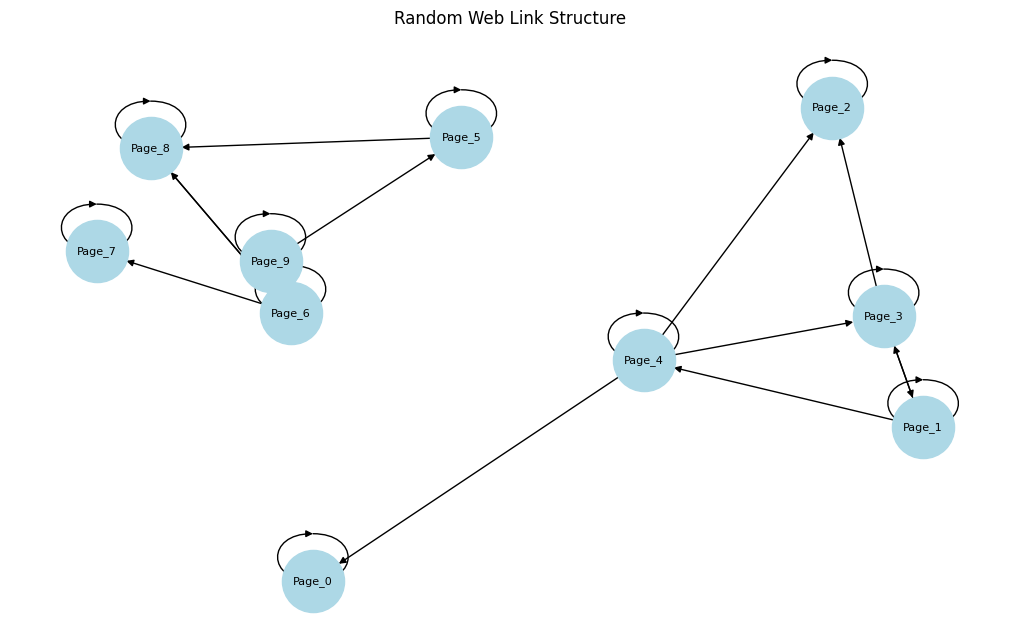

In [30]:
# visualize the link structure
import networkx as nx

N = 10  # number of pages
M = 20  # number of links
pages = generate_web_pages(N)
links = generate_links(pages, M)

G = nx.DiGraph()
for page, linked_pages in links.items():
    for linked_page in linked_pages:
        G.add_edge(page, linked_page)
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, k=1, iterations=50)
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', arrowsize=10, font_size=8)
plt.title('Random Web Link Structure')
plt.show()

In [31]:
# build the transition matrix for the Markov chain
def build_transition_matrix(pages, links):
    N = len(pages)
    page_index = {page: i for i, page in enumerate(pages)}
    P = np.zeros((N, N))
    
    for page, linked_pages in links.items():
        if linked_pages:
            i = page_index[page]
            for linked_page in linked_pages:
                j = page_index[linked_page]
                P[i, j] += 1
    
    # Normalize rows to sum to 1
    row_sums = P.sum(axis=1)
    for i in range(N):
        if row_sums[i] > 0:
            P[i] /= row_sums[i]
        else:
            P[i] = np.ones(N) / N  # If no outgoing links, assume uniform distribution
    
    return P

P = build_transition_matrix(pages, links)
assert np.allclose(P.sum(axis=1), 1), "Each row of the transition matrix must sum to 1"

In [32]:
# build a random walk simulator for the Markov chain
def random_walk(P, start_page, pages, d_factor=0.1, steps=100):
    page_index = {page: i for i, page in enumerate(pages)}
    current_index = page_index[start_page]
    visited_pages = [start_page]
    
    for _ in range(steps):
        # with probability d_factor, teleport to a random page
        if np.random.rand() < d_factor:
            current_index = np.random.randint(len(pages))
        else:
            next_index = np.random.choice(len(pages), p=P[current_index])
            current_index = next_index
        visited_pages.append(pages[current_index])
    
    return visited_pages

# simulate a random walk starting from a random page
start_page = np.random.choice(pages)
visited = random_walk(P, start_page, pages, d_factor=0.15, steps=1000)

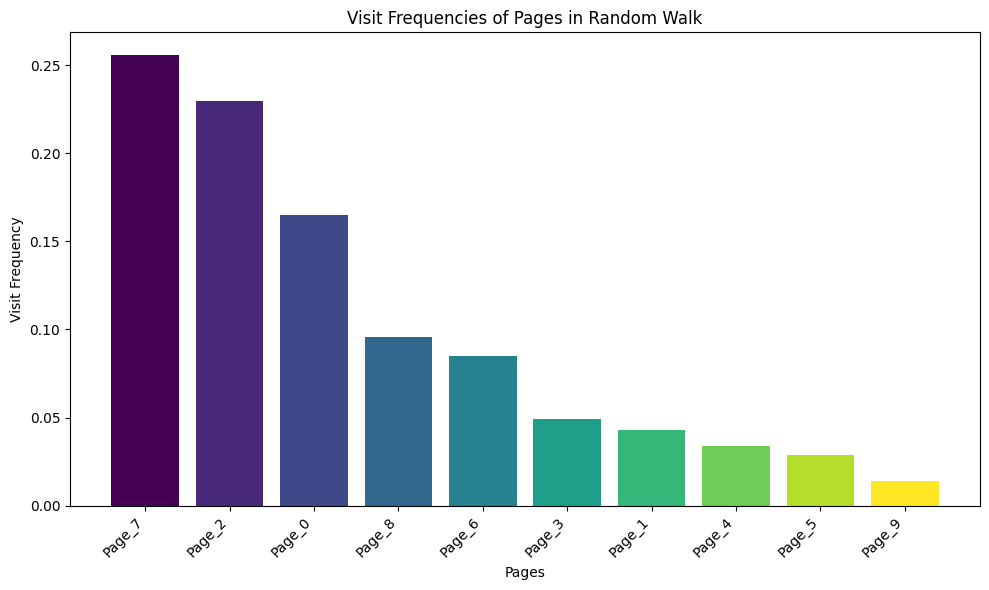

In [33]:
# count the frequency of visits to each page
from collections import Counter
visit_counts = Counter(visited)
visit_freq = {page: count / len(visited) for page, count in visit_counts.items()}

# plot the visit frequencies
plt.figure(figsize=(10, 6))
sorted_items = sorted(visit_freq.items(), key=lambda x: x[1], reverse=True)
pages_list = [p for p, _ in sorted_items]
frequencies_list = [f for _, f in sorted_items]
colors = plt.cm.viridis(np.linspace(0, 1, len(pages_list)))
plt.bar(pages_list, frequencies_list, color=colors)
plt.xlabel("Pages")
plt.ylabel("Visit Frequency")
plt.title("Visit Frequencies of Pages in Random Walk")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()